Idea:

$$
\begin{cases}
\dot x = \text{CHUA}(x) \\
x(0)=x_0 \\
\dot y = \text{CHUA}(y) + \varepsilon\cdot x  \\
y(0)=x_0
\end{cases}
$$

$$
\begin{cases}
\dot x = \text{CHUA}(x) \\
x(0)=x_0 \\
\dot z = \text{CHUA}(z) - \varepsilon(z-x)  \\
z(0)=x_0
\end{cases}
$$

In [3]:
from scipy.integrate import solve_ivp
import numpy as np
import matplotlib.pyplot as plt


In [4]:
def chua_model(t, xyz, alpha, beta, gamma, a, c):
    x,y,z = xyz 
    return np.array([
        alpha*(y-a*x**3-c*x),
        x-y+z, 
        -beta*y - gamma*z
    ])

In [5]:
def recursive_chua_2(t, vars, alpha, beta, gamma, a, c, eps):
    x1,x2,x3, y1,y2,y3 = vars 
    return np.array(
        [
            alpha*(x2-a*x1**3-c*x1),
            x1-x2+x3, 
            -beta*x2 - gamma*x3,

            alpha*(y2-a*y1**3-c*y1) + eps * x1,
            y1-y2+y3 + eps * x2, 
            -beta*y2 - gamma*y3 + eps * x3,

            
        ]
    )

def recursive_chua_3(t, vars, alpha, beta, gamma, a, c, eps1, eps2):
    x1,x2,x3, y1,y2,y3, z1, z2, z3 = vars 
    return np.array(
        [
            alpha*(x2-a*x1**3-c*x1),
            x1-x2+x3, 
            -beta*x2 - gamma*x3,

            alpha*(y2-a*y1**3-c*y1) + eps1 * x1,
            y1-y2+y3 + eps1 * x2, 
            -beta*y2 - gamma*y3 + eps1 * x3,

            alpha*(z2-a*z1**3-c*z1) + eps2 * y1,
            z1-z2+z3 + eps2 * y2, 
            -beta*z2 - gamma*z3 + eps2 * y3,

        ]
    )

In [4]:
T_RANGE = [0, 2500]
t_eval = np.arange(T_RANGE[0], T_RANGE[1], 0.01)
ALPHA, BETA, GAMMA, A, C, EPS1, EPS2 = (10, 16, 0, 1, -0.143, 0.1, 0.1)

sol = solve_ivp(recursive_chua_3, T_RANGE, [0.0001, 0.1, 0,  0.0001, 0.1, 0, 0.0001, 0.1, 0], 
                args=(ALPHA, BETA, GAMMA, A, C, EPS1, EPS2), t_eval=t_eval)

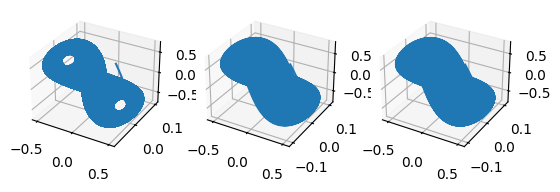

In [5]:
fig, axes = plt.subplots(1, 3, subplot_kw=dict(projection='3d'))

axes[1].plot(sol.y[3, :],sol.y[4, :],sol.y[5, :])
axes[2].plot(sol.y[6, :],sol.y[7, :],sol.y[8, :])
axes[0].plot(sol.y[0, :],sol.y[1, :],sol.y[2, :])

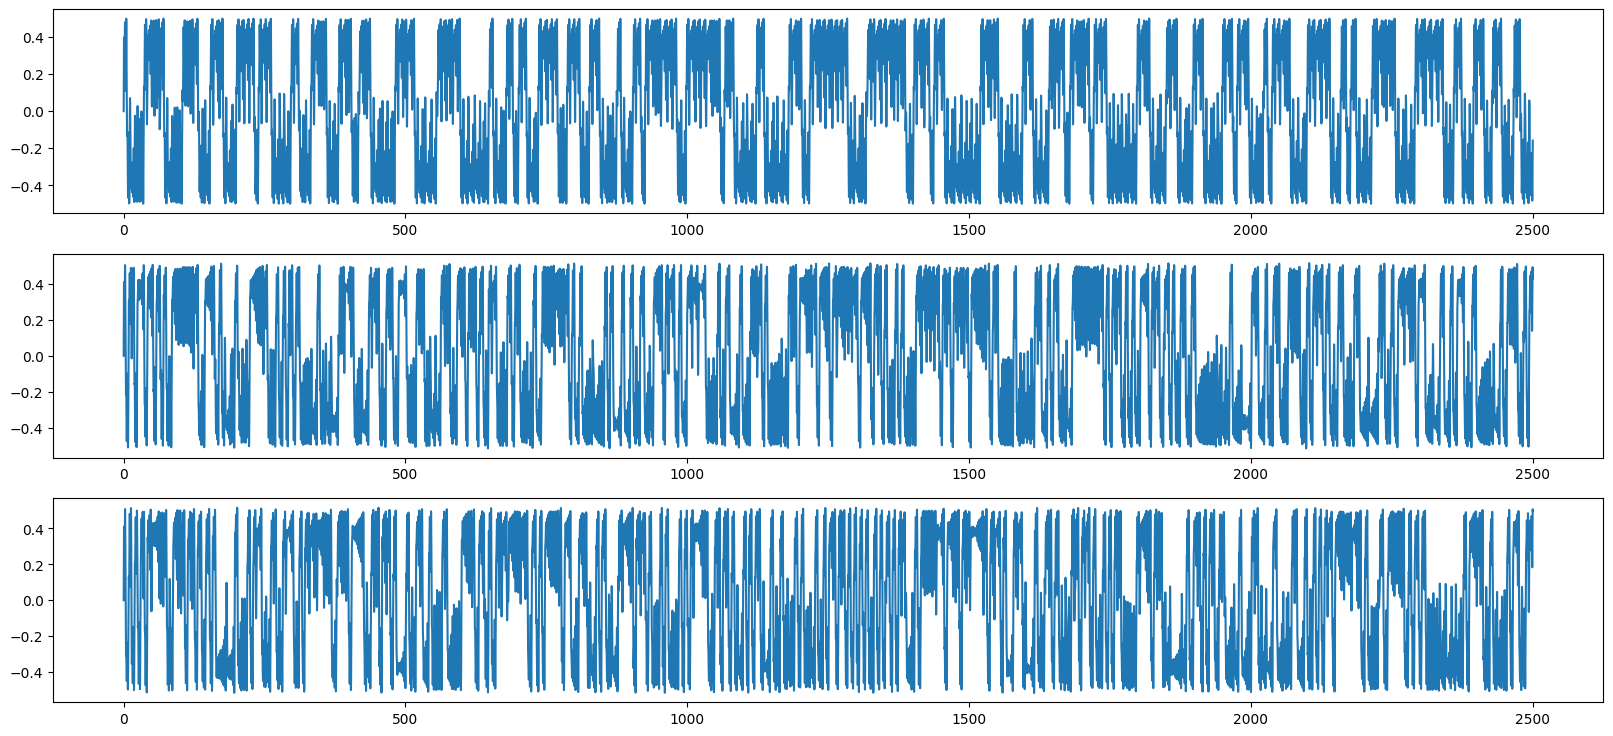

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(20, 9))

i = 0
axes[0].plot(sol.t, sol.y[0+i, :])
axes[1].plot(sol.t, sol.y[3+i, :])
axes[2].plot(sol.t, sol.y[6+i, :])


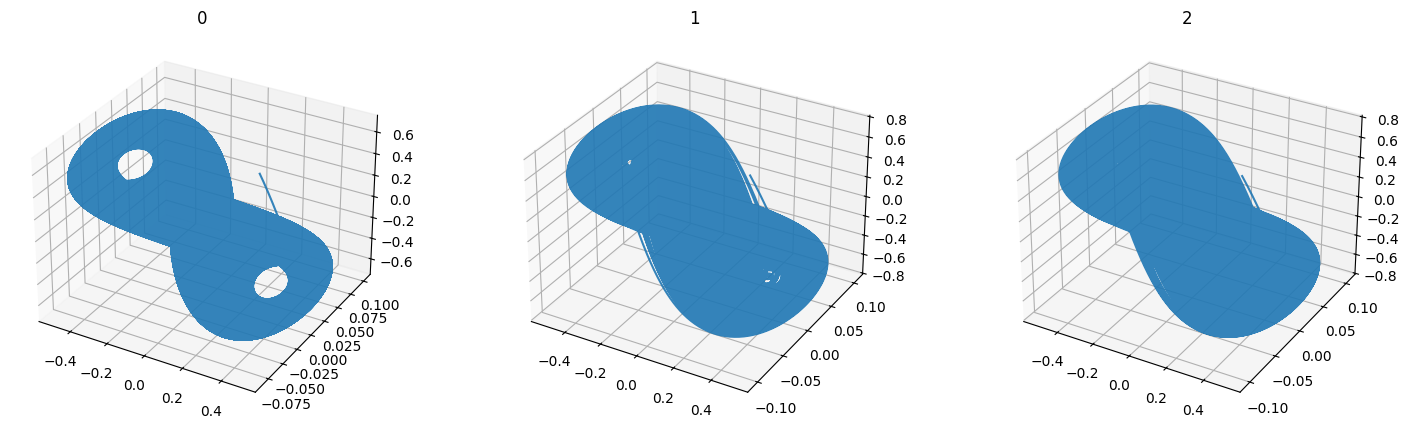

In [16]:

ncols = 3
nrows = 1

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(6*ncols, 5*nrows),
    subplot_kw={"projection": "3d"}
)
axes = np.atleast_2d(axes)

for i in range(3):
    r, c = divmod(i, ncols)
    ax = axes[r, c]

    ax.plot(
        sol.y[3*i],
        sol.y[3*i+1],
        sol.y[3*i+2],
        alpha=0.9
    )
    ax.set_title(f"{i}")


<Axes: ylabel='Count'>

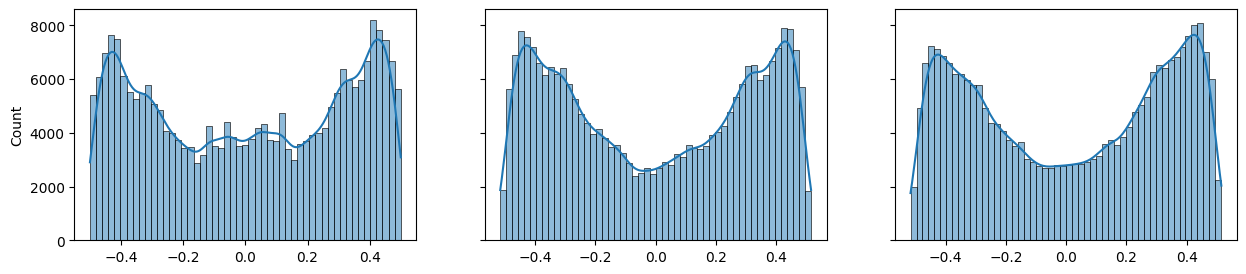

In [7]:
from seaborn import histplot

fig, axes = plt.subplots(1, 3, figsize=(15, 3), sharey=True)

histplot(sol.y[0, :], kde=True, ax=axes[0])
histplot(sol.y[3, :], kde=True, ax=axes[1])
histplot(sol.y[6, :], kde=True, ax=axes[2])


# generalize

$$
\begin{gather}
\underline{\dot x_1} = \texttt{CHUA}(\underline{\dot x_1}) \\
\underline{\dot x_2} = \texttt{CHUA}(\underline{\dot x_2})+\varepsilon_1(\underline{\dot x_1}) \\
\vdots \nonumber \\ 
\underline{\dot x_k} = \texttt{CHUA}(\underline{\dot x_k})+\varepsilon_{k-1}(\underline{\dot x_{k-1}}) \\

\end{gather}
$$

In [1]:
def recursive_chua_n(t, vars, alpha, beta, gamma, a, c, eps):
    vars = np.asarray(vars)
    eps = np.asarray(eps)

    n = len(vars) // 3
    dvars = np.zeros_like(vars, dtype=float)

    for i in range(n):
        u1, u2, u3 = vars[3*i : 3*i + 3]

        du = np.array([
            alpha * (u2 - a*u1**3 - c*u1),
            u1 - u2 + u3,
            -beta*u2 - gamma*u3
        ])

        if i > 0:
            prev = vars[3*(i-1) : 3*(i-1) + 3]
            du += eps[i-1] * prev

        dvars[3*i : 3*i + 3] = du

    return dvars

In [10]:
K = 4

T_RANGE = [0, 2500]
t_eval = np.arange(T_RANGE[0], T_RANGE[1], 0.01)
ALPHA, BETA, GAMMA, A, C = (10, 16, 0, 1, -0.143)
init_cond = np.tile([0.0001, 0.1, 0], K)
EPSES = [1 for _ in range(K)]

sol = solve_ivp(recursive_chua_n, T_RANGE, init_cond, 
                args=[ALPHA, BETA, GAMMA, A, C, EPSES] , t_eval=t_eval)


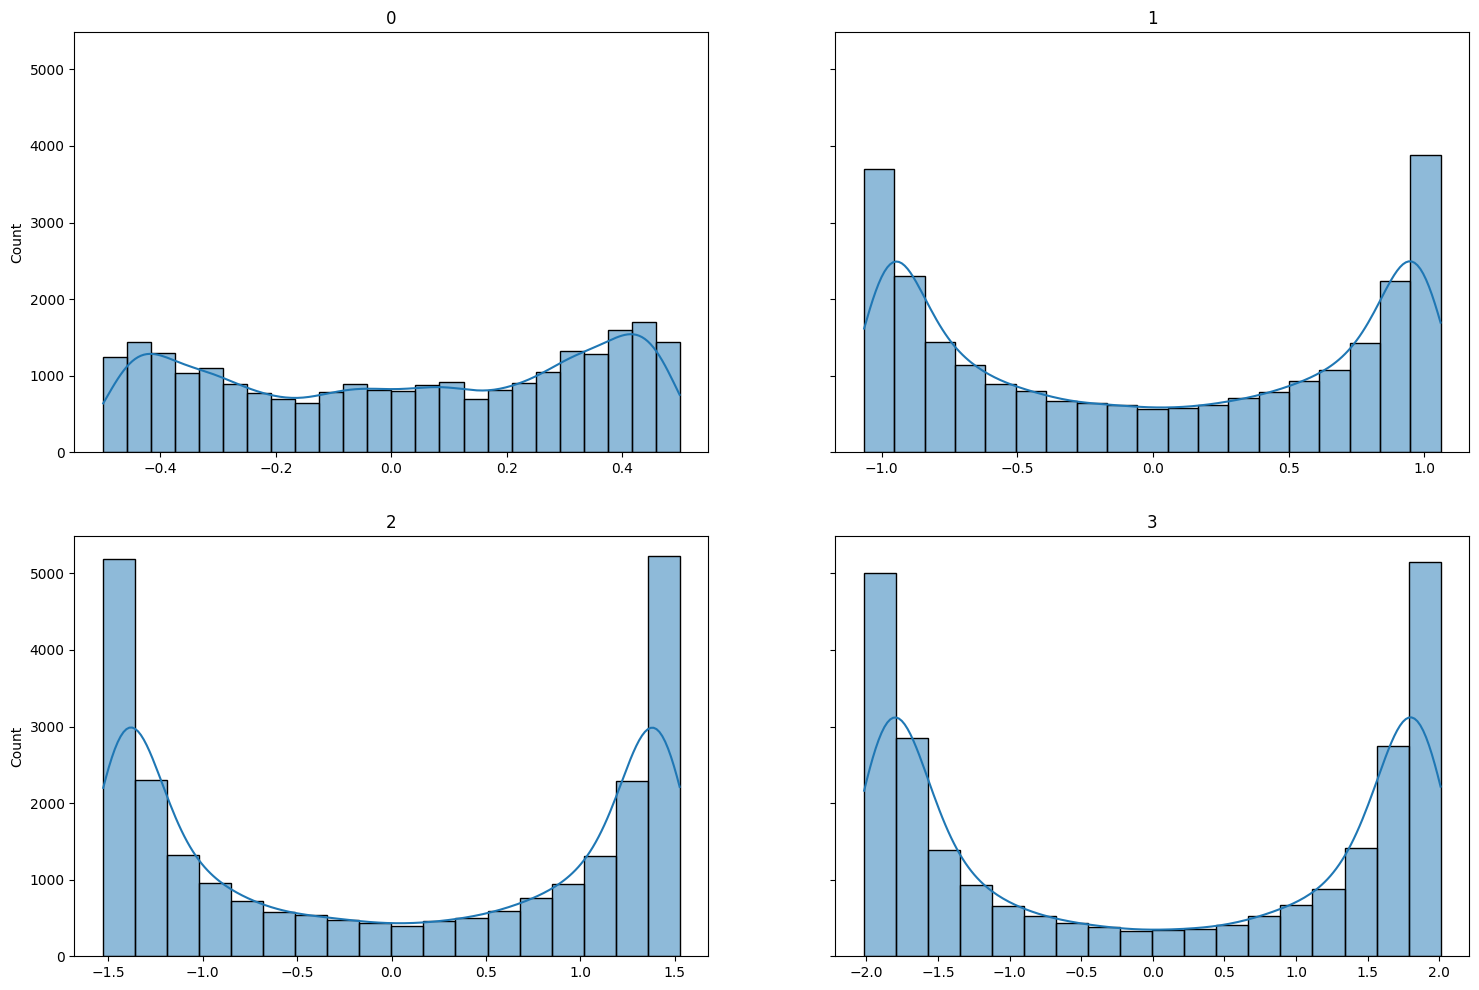

In [15]:

from seaborn import histplot

fig, axes = plt.subplots(2, 2, figsize=(18, 12), sharey=True)

for i in range(K):
    x, y  = divmod(i, 2)
    axes[x,y].set_title(i)
    histplot(sol.y[3*i, ::10], kde=True, ax=axes[x, y])


Text(0.5, 0.98, '$2500 \\leq t \\leq 2000$')

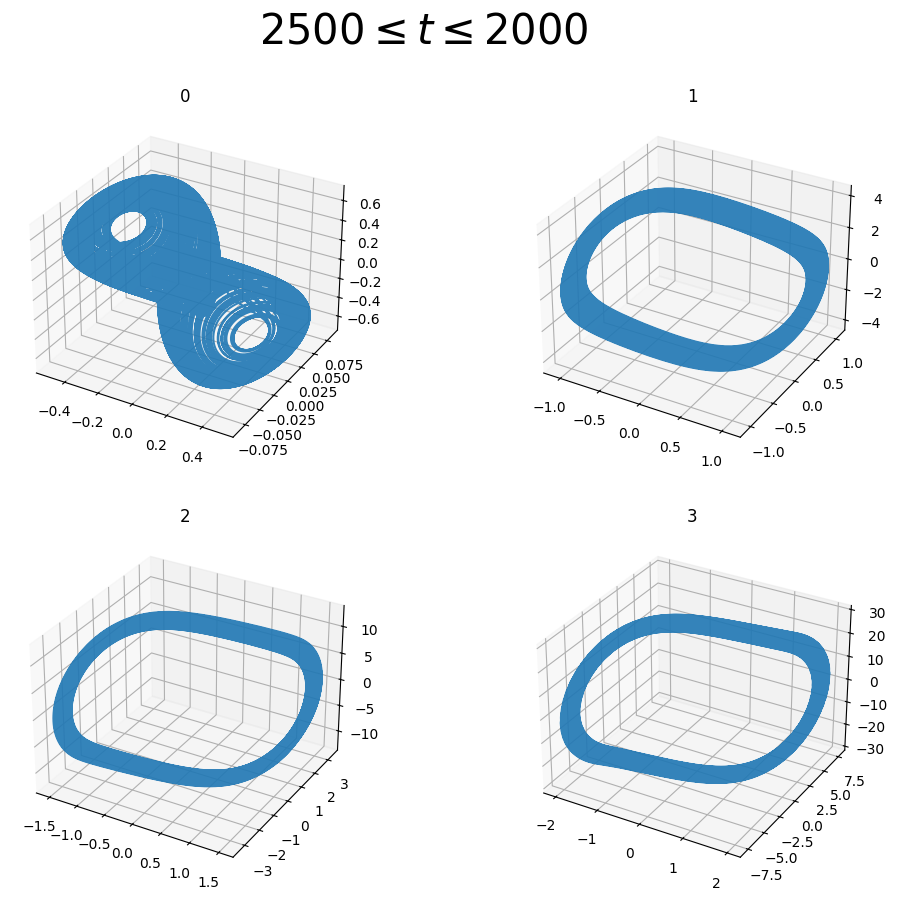

In [13]:
ncols = 2
nrows = 2

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(6*ncols, 5*nrows),
    subplot_kw={"projection": "3d"}
)
axes = np.atleast_2d(axes)

for i in range(K):
    r, c = divmod(i, ncols)
    ax = axes[r, c]

    ax.plot(
        sol.y[3*i, 2000*100:],
        sol.y[3*i+1, 2000*100:],
        sol.y[3*i+2, 2000*100:],
        alpha=0.9
    )
    ax.set_title(f"{i}")

plt.suptitle(r"$2500 \leq t \leq 2000$", size=30)

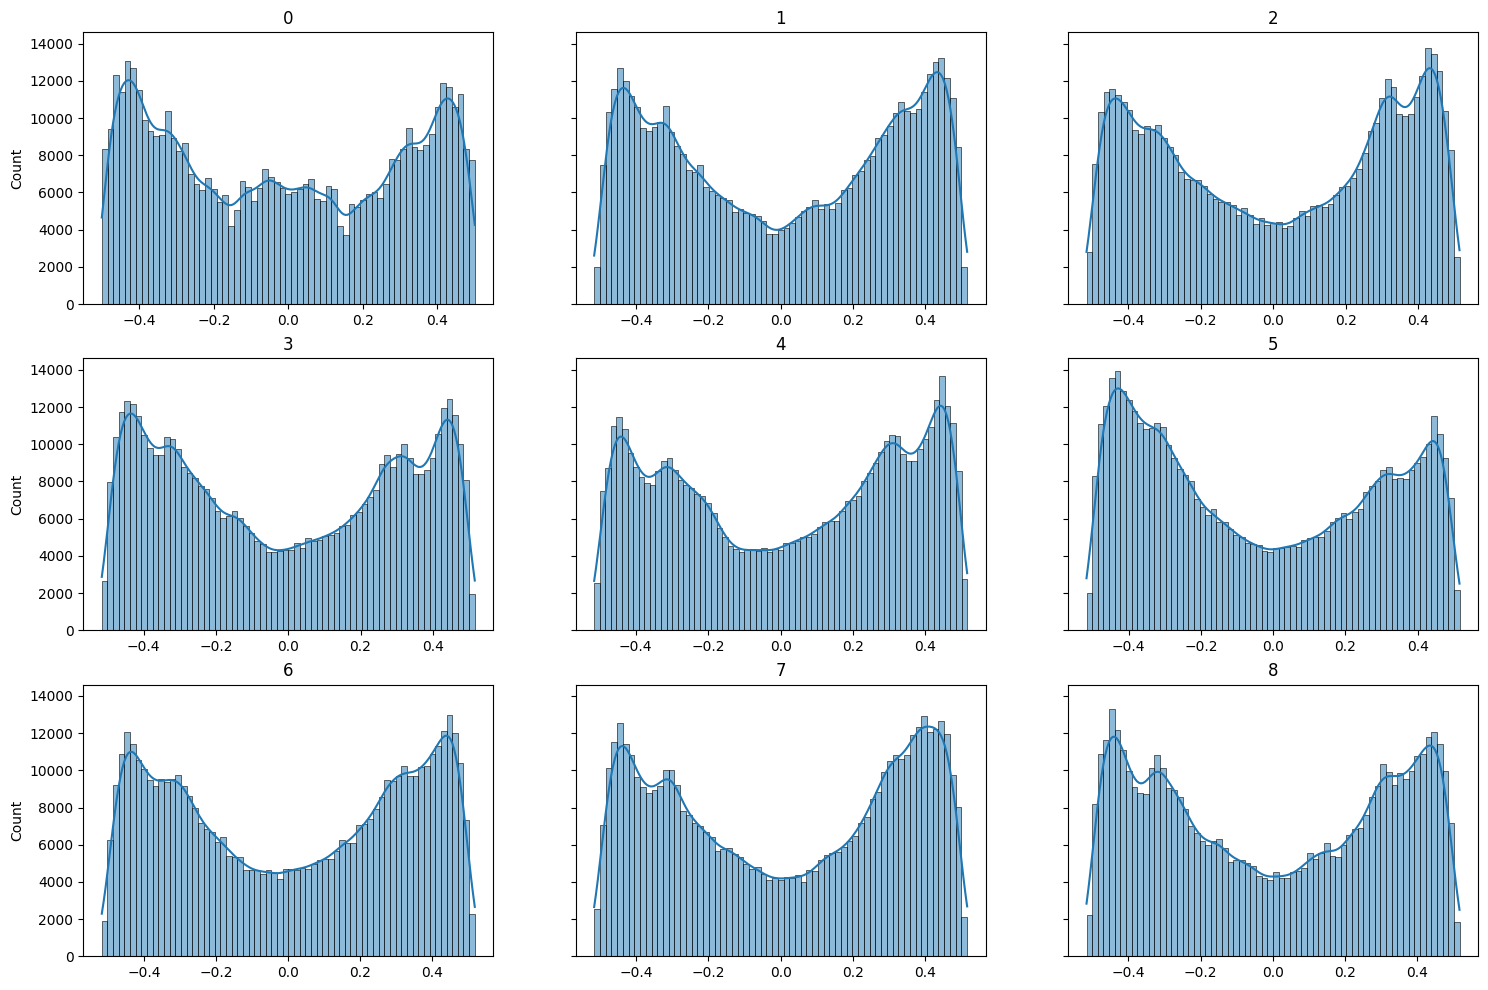

In [153]:
K = 9

T_RANGE = [0, 2500]
t_eval = np.arange(T_RANGE[0], T_RANGE[1], 0.005)
ALPHA, BETA, GAMMA, A, C = (10, 16, 0, 1, -0.143)
init_cond = np.tile([0.0001, 0.1, 0], K)
EPSES = [-0.1 for _ in range(K)]

sol = solve_ivp(recursive_chua_n, T_RANGE, init_cond, 
                args=[ALPHA, BETA, GAMMA, A, C, EPSES] , t_eval=t_eval)

from seaborn import histplot

fig, axes = plt.subplots(3, 3, figsize=(18, 12), sharey=True)

for i in range(K):
    x, y  = divmod(i, 3)
    axes[x,y].set_title(i)
    histplot(sol.y[3*i, :], kde=True, ax=axes[x, y])


Text(0.5, 0.98, '$2500 \\leq t \\leq 2000$')

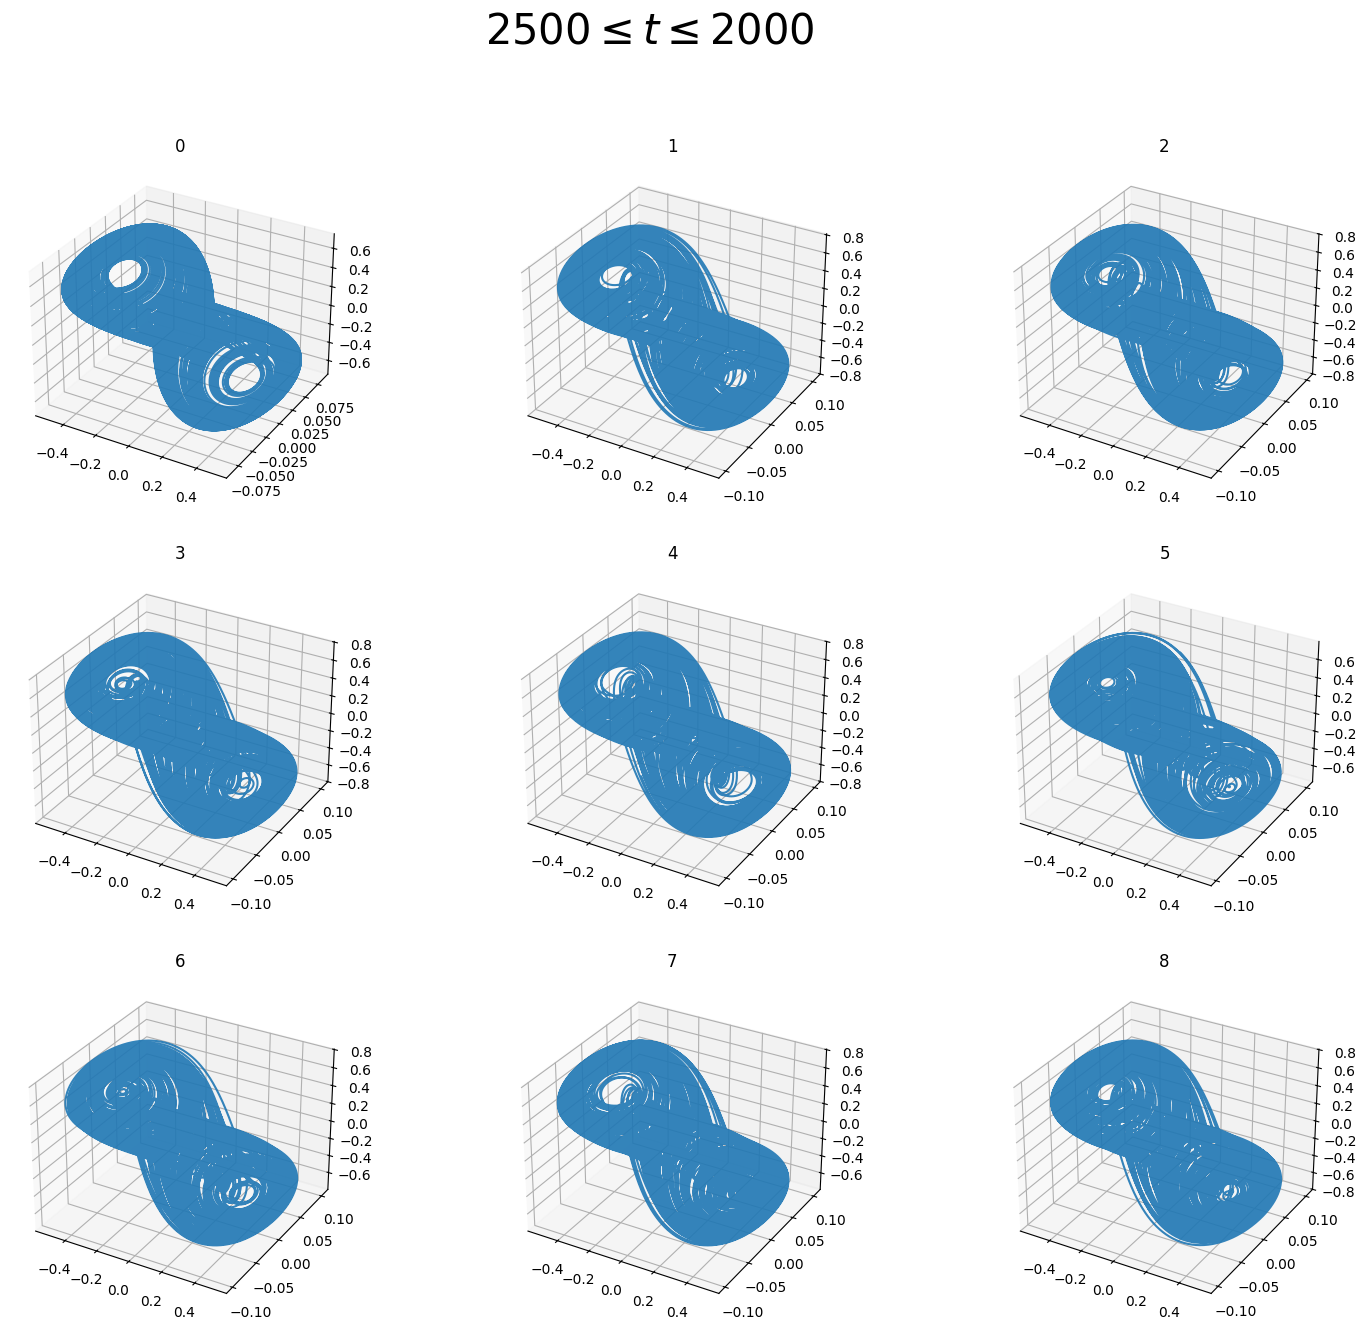

In [156]:
ncols = 3
nrows = 3

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(6*ncols, 5*nrows),
    subplot_kw={"projection": "3d"}
)
axes = np.atleast_2d(axes)

for i in range(K):
    r, c = divmod(i, ncols)
    ax = axes[r, c]

    ax.plot(
        sol.y[3*i, 2000*200:],
        sol.y[3*i+1, 2000*200:],
        sol.y[3*i+2, 2000*200:],
        alpha=0.9
    )
    ax.set_title(f"{i}")

plt.suptitle(r"$2500 \leq t \leq 2000$", size=30)

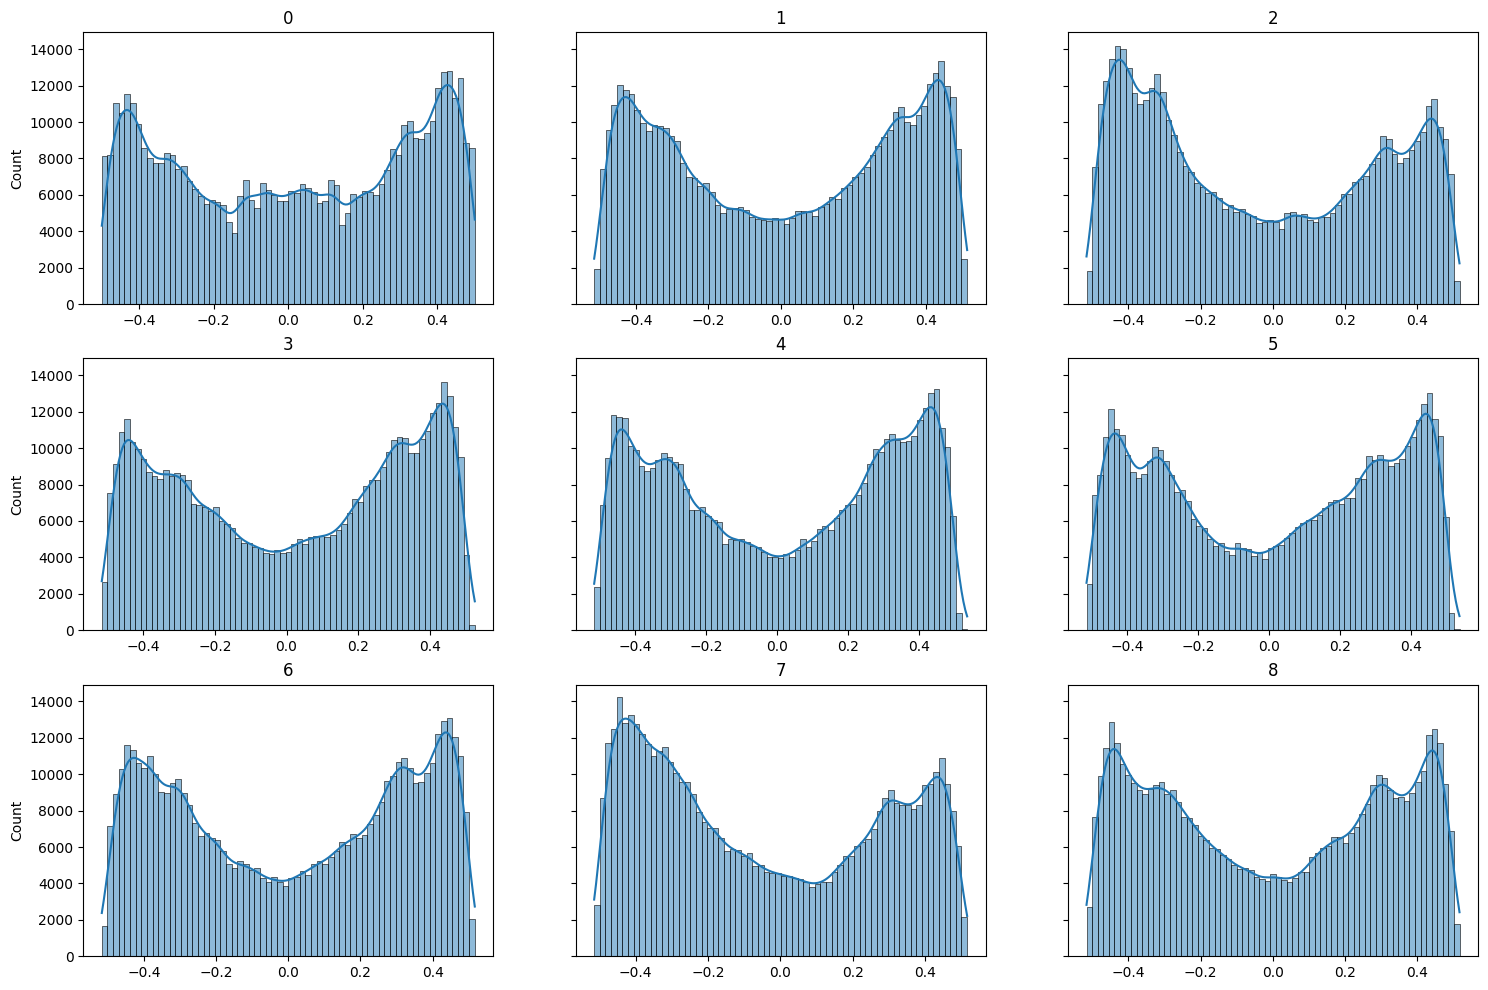

In [33]:
K = 9

T_RANGE = [0, 2500]
t_eval = np.arange(T_RANGE[0], T_RANGE[1], 0.005)
ALPHA, BETA, GAMMA, A, C = (10, 16, 0, 1, -0.143)
init_cond = np.repeat([0.0001, 0.1, 0], K)
EPSES = [0.1 for _ in range(K)]

sol = solve_ivp(recursive_chua_n, T_RANGE, init_cond, 
                args=[ALPHA, BETA, GAMMA, A, C, EPSES] , t_eval=t_eval)

from seaborn import histplot

fig, axes = plt.subplots(3, 3, figsize=(18, 12), sharey=True)

for i in range(K):
    x, y  = divmod(i, 3)
    axes[x,y].set_title(i)
    histplot(sol.y[3*i, :], kde=True, ax=axes[x, y])


Text(0.5, 0.98, '$2500 \\leq t \\leq 2250$')

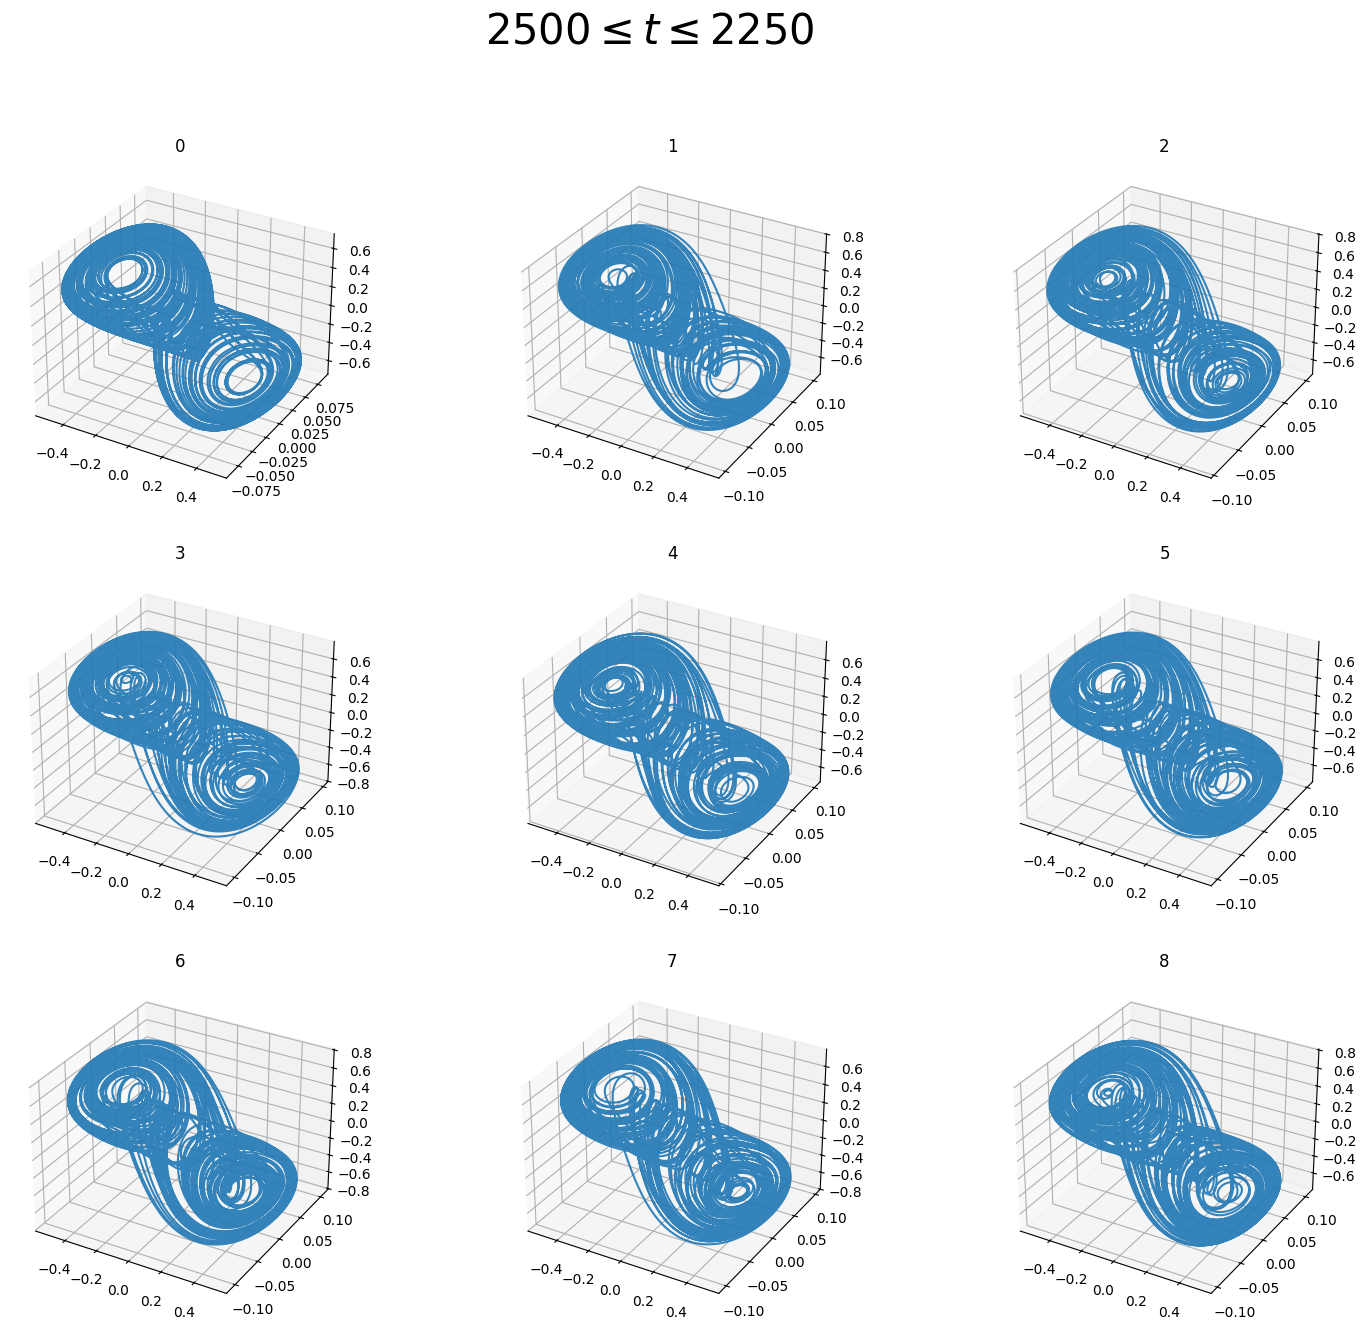

In [35]:
ncols = 3
nrows = 3

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(6*ncols, 5*nrows),
    subplot_kw={"projection": "3d"}
)
axes = np.atleast_2d(axes)

for i in range(K):
    r, c = divmod(i, ncols)
    ax = axes[r, c]

    ax.plot(
        sol.y[3*i, 450000:],
        sol.y[3*i+1, 450000:],
        sol.y[3*i+2, 450000:],
        alpha=0.9
    )
    ax.set_title(f"{i}")

plt.suptitle(r"$2500 \leq t \leq 2250$", size=30)

# another way

$$
\dot x = F(x), \dot y = F(x) + e(y-x), y_0 = x_0 
$$

In [134]:
def recursive_chua_alt(t, vars, alpha, beta, gamma, a, c, eps):
    x1,x2,x3, y1,y2,y3 = vars 

    return np.array(
        [
            alpha*(x2-a*x1**3-c*x1),
            x1-x2+x3, 
            -beta*x2 - gamma*x3,

            alpha*(y2-a*y1**3-c*y1) + eps *(y1-x1),
            y1-y2+y3 + eps *(y2-x2), 
            -beta*y2 - gamma*y3 + eps *(y3-x3)
        ]
    )

In [135]:
# epsilon > 0

In [163]:
ALPHA, BETA, GAMMA, A, C, EPS = (10, 16, 0, 1, -0.143, 0.1)
T_RANGE = [0, 2000]
t_eval = np.arange(T_RANGE[0], T_RANGE[1], 0.001)

sol = solve_ivp(recursive_chua_alt, T_RANGE, [0.0001, 0.1, 0,  0.0001, 0.1, 0], args=(ALPHA, BETA, GAMMA, A, C, EPS), t_eval=t_eval)

<Axes: ylabel='Count'>

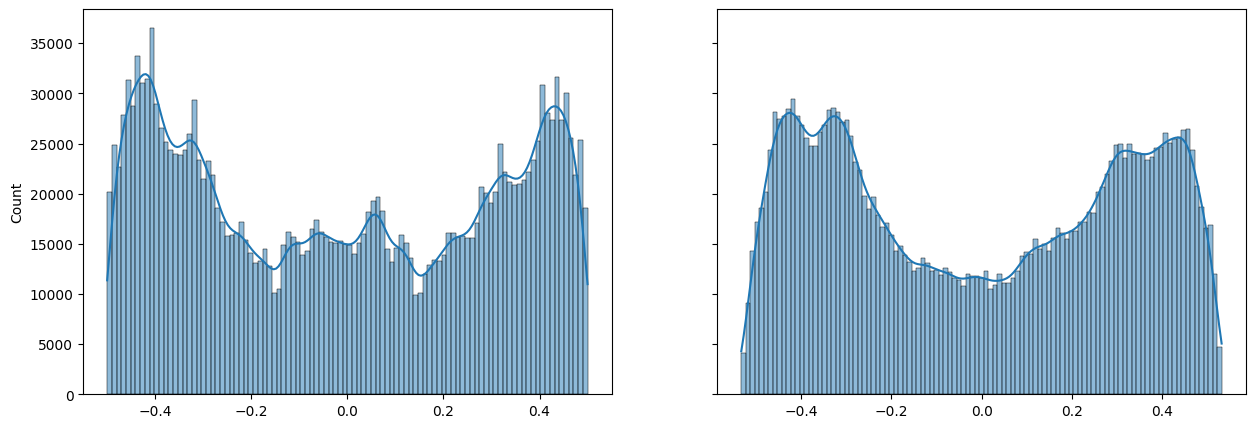

In [164]:
from seaborn import histplot

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

histplot(sol.y[0, :], kde=True, ax=axes[0])
histplot(sol.y[3, :], kde=True, ax=axes[1])


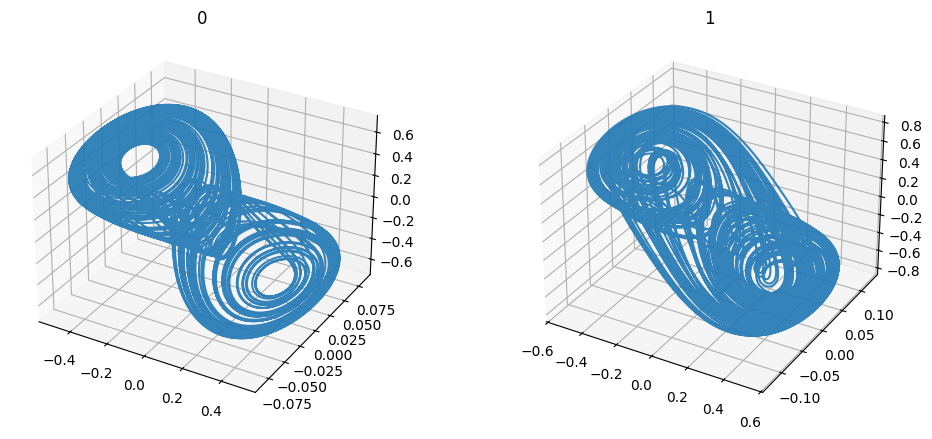

In [165]:

ncols = 2
nrows = 1

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(6*ncols, 5*nrows),
    subplot_kw={"projection": "3d"}
)
axes = np.atleast_2d(axes)

for i in range(2):
    r, c = divmod(i, ncols)
    ax = axes[r, c]

    ax.plot(
        sol.y[3*i, 1700*1000:],
        sol.y[3*i+1, 1700*1000:],
        sol.y[3*i+2, 1700*1000:],
        alpha=0.9
    )
    ax.set_title(f"{i}")


In [ ]:
# epsilon < 0

In [138]:
ALPHA, BETA, GAMMA, A, C, EPS = (10, 16, 0, 1, -0.143, -0.1)
T_RANGE = [0, 2000]
t_eval = np.arange(T_RANGE[0], T_RANGE[1], 0.001)

sol = solve_ivp(recursive_chua_alt, T_RANGE, [0.0001, 0.1, 0,  0.0001, 0.1, 0], args=(ALPHA, BETA, GAMMA, A, C, EPS), t_eval=t_eval)

<Axes: ylabel='Count'>

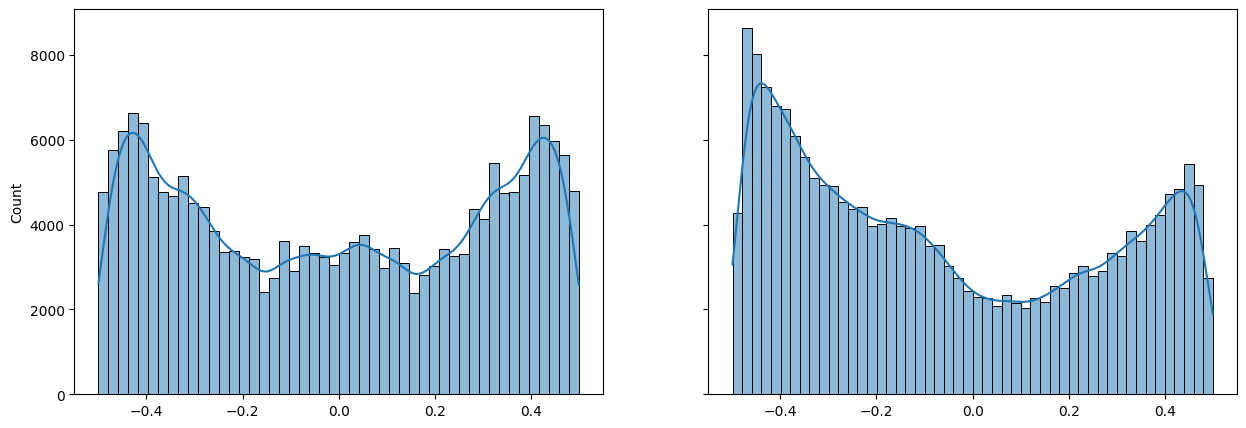

In [140]:
from seaborn import histplot

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

histplot(sol.y[0, ::10], kde=True, ax=axes[0])
histplot(sol.y[3, ::10], kde=True, ax=axes[1])


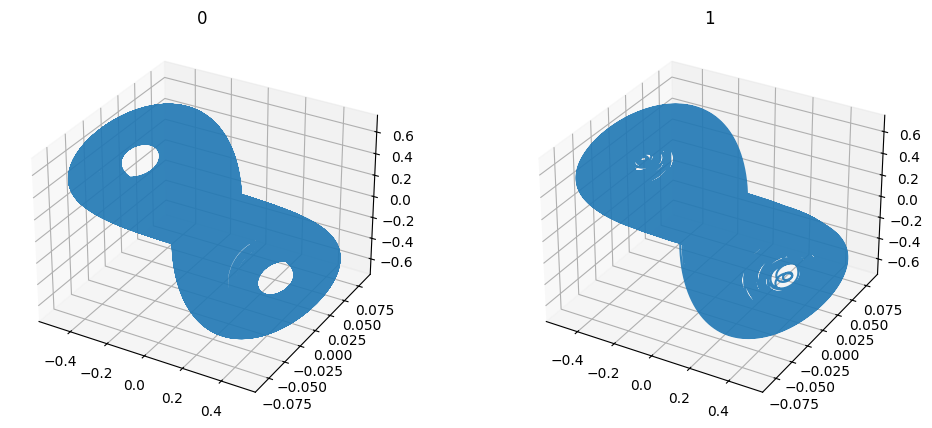

In [142]:

ncols = 2
nrows = 1

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(6*ncols, 5*nrows),
    subplot_kw={"projection": "3d"}
)
axes = np.atleast_2d(axes)

for i in range(2):
    r, c = divmod(i, ncols)
    ax = axes[r, c]

    ax.plot(
        sol.y[3*i, 150*1000:],
        sol.y[3*i+1, 150*1000:],
        sol.y[3*i+2, 150*1000:],
        alpha=0.9
    )
    ax.set_title(f"{i}")


In [59]:
sol.t[1000*1000]

np.float64(1000.0)

In [42]:
len(sol.t)

2000000

What if we generalize as before, so we instead have

$$
\begin{gather}
\underline{\dot x_1} = \texttt{CHUA}(\underline{\dot x_1}) \\
\underline{\dot x_2} = \texttt{CHUA}(\underline{\dot x_2})+\varepsilon_1(\underline{\dot x_1}-\underline{\dot x_2}) \\
\vdots \nonumber \\ 
\underline{\dot x_k} = \texttt{CHUA}(\underline{\dot x_k})+\varepsilon_{k-1}(\underline{\dot x_{k}}-\underline{\dot x_{k-1}}) \\

\end{gather}
$$

In [ ]:
ALPHA, BETA, GAMMA, A, C, EPS = (10, 16, 0, 1, -0.143, -0.1)
T_RANGE = [0, 2000]
t_eval = np.arange(T_RANGE[0], T_RANGE[1], 0.001)

sol = solve_ivp(recursive_chua_alt, T_RANGE, [0.0001, 0.1, 0,  0.0001, 0.1, 0], args=(ALPHA, BETA, GAMMA, A, C, EPS), t_eval=t_eval)

In [146]:
def recursive_chua_alt_n(t, vars, alpha, beta, gamma, a, c, eps):
    vars = np.asarray(vars)
    eps = np.asarray(eps)

    n = len(vars) // 3
    dvars = np.zeros_like(vars, dtype=float)

    for i in range(n):
        u1, u2, u3 = vars[3*i : 3*i + 3]

        du = np.array([
            alpha * (u2 - a*(u1**3) - c*u1),
            u1 - u2 + u3,
            -beta*u2 - gamma*u3
        ])

        if i > 0:
            prev = dvars[3*(i-1) : 3*(i-1) + 3]
            du += eps[i-1] * (vars[3*i: 3*i+3] - prev)

        dvars[3*i : 3*i + 3] = du


    return dvars

In [147]:
K = 9
ALPHA, BETA, GAMMA, A, C = (10, 16, 0, 1, -0.143)
T_RANGE = [0, 2500]
t_eval = np.arange(T_RANGE[0], T_RANGE[1], 0.001)

init_cond = np.tile([0.0001, 0.1, 0], K)
EPSES = [-0.1 for _ in range(K)]

sol = solve_ivp(recursive_chua_alt_n, T_RANGE, init_cond, 
                args=[ALPHA, BETA, GAMMA, A, C, EPSES] , t_eval=t_eval)

print("aaa")


aaa


Text(0.5, 0.98, 'Evolution of the Statistical Distribution (in $x^{(i)}$) across Recursive Iterations')

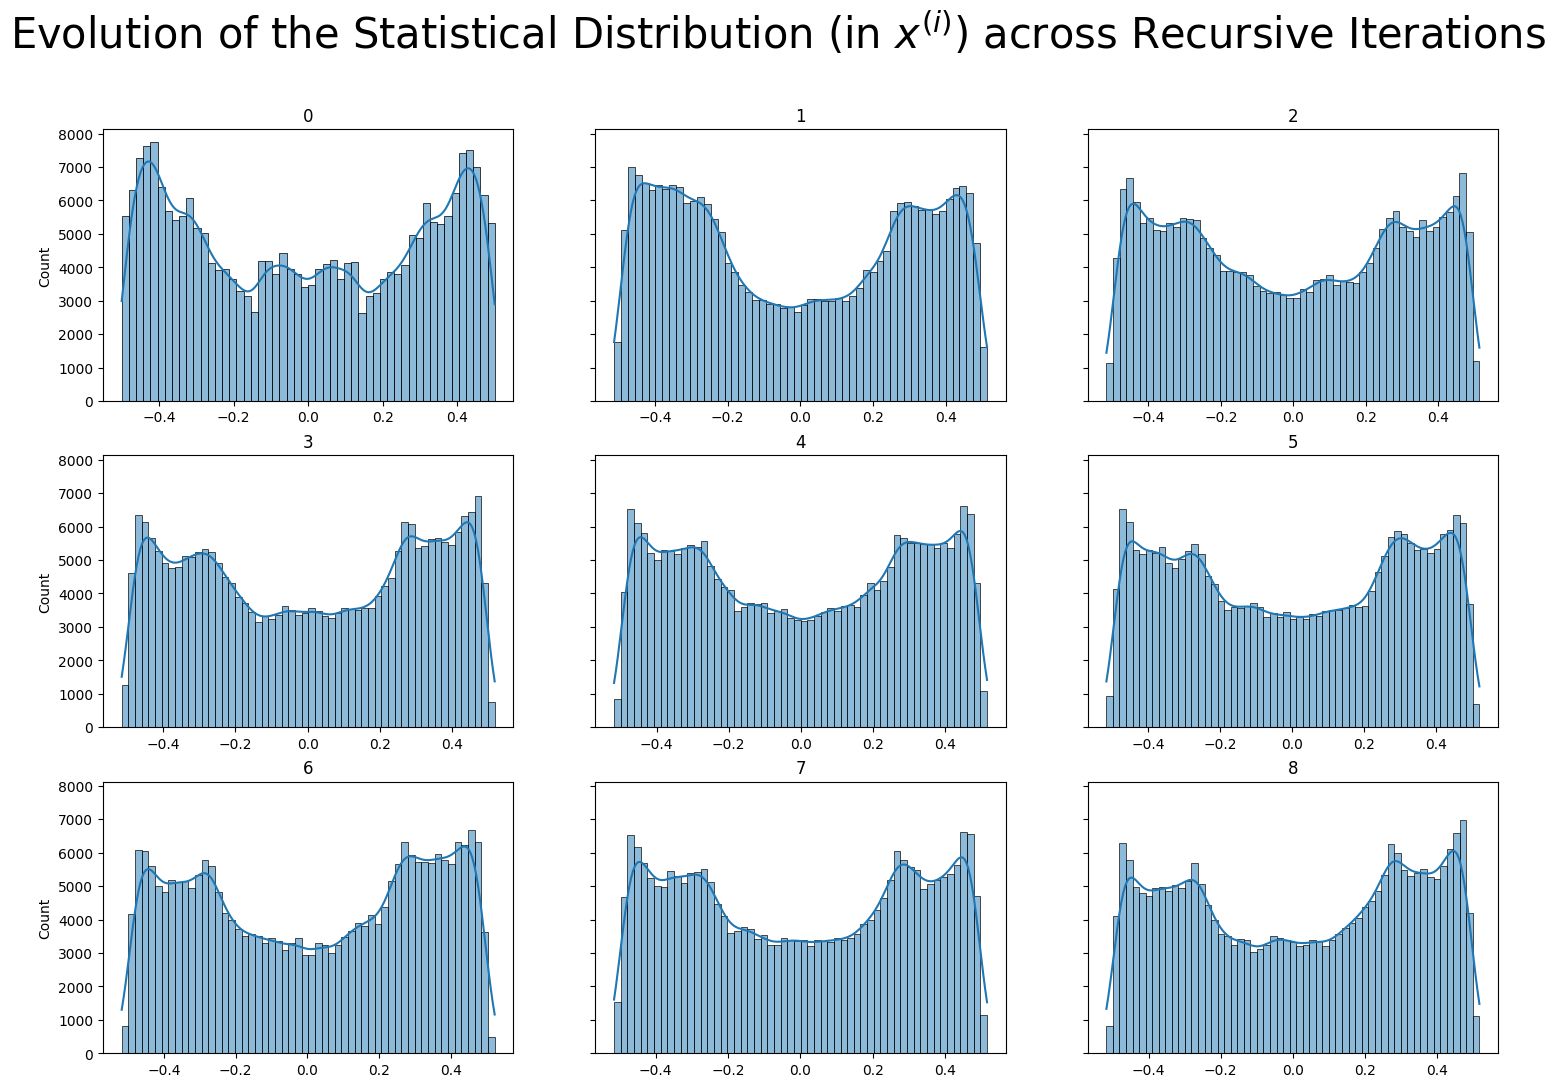

In [148]:

from seaborn import histplot

fig, axes = plt.subplots(3, 3, figsize=(18, 12), sharey=True)

for i in range(K):
    x, y  = divmod(i, 3)
    axes[x,y].set_title(i)
    histplot(sol.y[3*i, ::10], kde=True, ax=axes[x, y])

plt.suptitle("Evolution of the Statistical Distribution (in $x^{(i)}$) across Recursive Iterations", size=30)


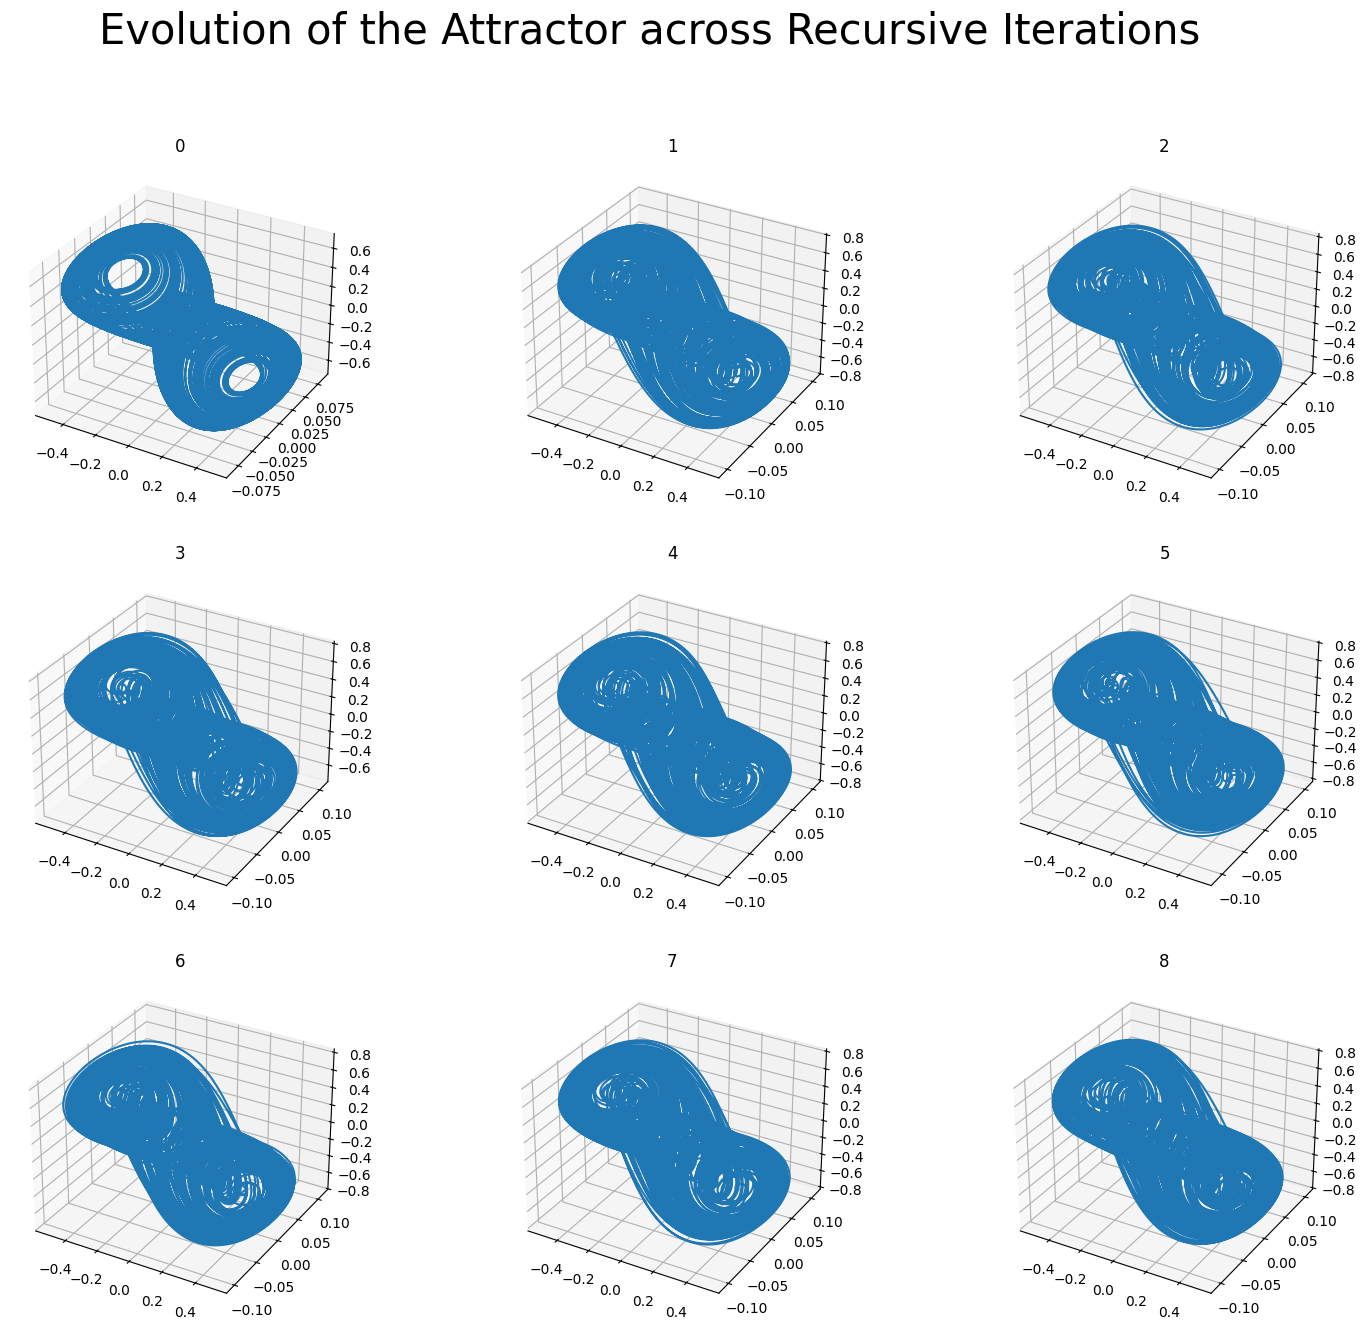

In [150]:
import math

ncols = 3
nrows = math.ceil(K / ncols)

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(6*ncols, 5*nrows),
    subplot_kw={"projection": "3d"}
)
axes = np.atleast_2d(axes)

for i in range(K):
    r, c = divmod(i, ncols)
    ax = axes[r, c]

    ax.plot(
        sol.y[3*i, 2000*1000:],
        sol.y[3*i+1, 2000*1000:],
        sol.y[3*i+2, 2000*1000:],
    )
    ax.set_title(f"{i}")

plt.suptitle("Evolution of the Attractor across Recursive Iterations", size=30)
plt.show()